In [34]:
import numpy as np
import torch.nn as nn 
import torch.optim as optim
import matplotlib.pyplot as plt
import importlib
import utils 
#reload the utils module to get the latest changes
importlib.reload(utils)
from torch.utils.data import DataLoader, TensorDataset
from pathlib import Path
from utils import (plot_class_distribution, show_class_distribution, create_train_test_val_split , 
                   display_random_samples , fix_images, check_duplicates, remove_duplicates)
from data_fetch import download_dataset


# Globals

In [ ]:
# PATHS AND SEED --!-- DO NOT EDIT --!--
ROOT_DIR = Path('./data/')
DATA_DIR = ROOT_DIR / 'data'
TEST_DIR = ROOT_DIR / 'test/'
TRAIN_DIR = ROOT_DIR / 'train/'
VAL_DIR = ROOT_DIR / 'val/'
SEED = 42

# HYPERPARAMETERS
BATCH_SIZE = 32
IMG_SIZE = (32, 32)
LEARNING_RATE = 0.001
NUM_EPOCHS = 10

# Data Fetching & Initial Cleaning

In [8]:
download_dataset('harikrishnacs/sentinel-1-sar-oil-spill-detection-dataset', ROOT_DIR)

Dataset URL: https://www.kaggle.com/datasets/harikrishnacs/sentinel-1-sar-oil-spill-detection-dataset
Done! Dataset location: /home/andrealoy/Documents/repos/sentinel-1-oil-detection/data
Folders found: ['metadata', 'data']


**Deleting the Samples folder as we will not use it**

In [12]:
!rm -rf {DATA_DIR / 'Samples'}
print("Removed 'Samples' directory from the dataset")

Removed 'Samples' directory from the dataset


In [13]:
plot_class_distribution(DATA_DIR)

In [14]:
show_class_distribution(DATA_DIR)

Class: S1SAR_UnBalanced_400by400_Class_0 - Number of samples: 3725
Class: S1SAR_UnBalanced_400by400_Class_1 - Number of samples: 1905


In [17]:
fix_images(DATA_DIR)

Accepted file: data/data/S1SAR_UnBalanced_400by400_Class_0/0/422_10000_6200_img_8UXGVkszCbidTR49_GBR_cls_0.jpg of type: jpeg
Accepted file: data/data/S1SAR_UnBalanced_400by400_Class_0/0/2857_9000_11200_img_NgkRiqvlSMUKRxSO_GBR_cls_0.jpg of type: jpeg
Accepted file: data/data/S1SAR_UnBalanced_400by400_Class_0/0/0_0_0_img_CFAY073B8sznfZJG_GBR_cls_0.jpg of type: jpeg
Accepted file: data/data/S1SAR_UnBalanced_400by400_Class_0/0/2_400_0_img_0t9JBHeOeBHgaLmJ_JAV_cls_0.jpg of type: jpeg
Accepted file: data/data/S1SAR_UnBalanced_400by400_Class_0/0/2690_2600_9400_img_8jmWSIh9LhIh4p4e_GBR_cls_0.jpg of type: jpeg
Accepted file: data/data/S1SAR_UnBalanced_400by400_Class_0/0/15_600_600_img_yypoVwlHZPchMcLa_GBR_cls_0.jpg of type: jpeg
Accepted file: data/data/S1SAR_UnBalanced_400by400_Class_0/0/1064_9200_7400_img_xCVKEyUQBMP2ef8r_GBR_cls_0.jpg of type: jpeg
Accepted file: data/data/S1SAR_UnBalanced_400by400_Class_0/0/460_5400_3000_img_lHgjbs0x2eQq1CKp_GBR_cls_0.jpg of type: jpeg
Accepted file: data/

In [18]:
show_class_distribution(DATA_DIR)

Class: S1SAR_UnBalanced_400by400_Class_0 - Number of samples: 3725
Class: S1SAR_UnBalanced_400by400_Class_1 - Number of samples: 1905


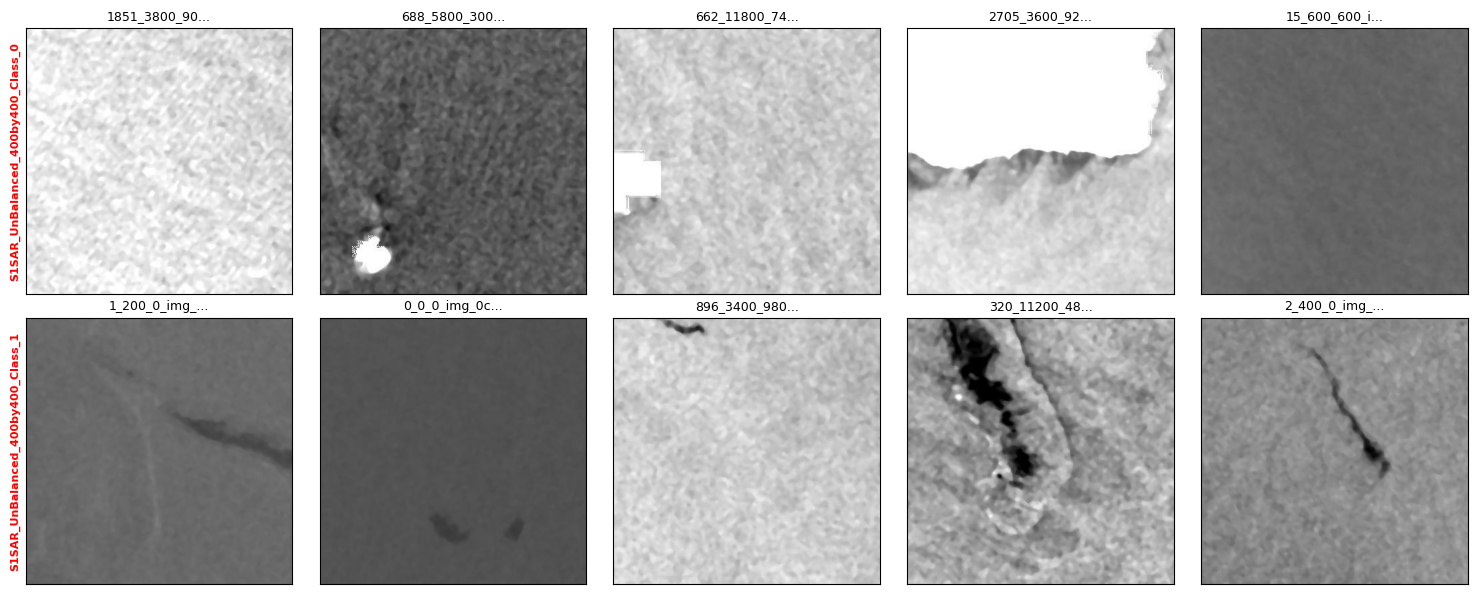

In [26]:
display_random_samples(DATA_DIR)

In [28]:
create_train_test_val_split(
    DATA_DIR,
    output_dir=ROOT_DIR,
    train_ratio=0.8,
    val_ratio=0.1,
    test_ratio=0.1,
    seed=SEED,
 )

Dataset split completed. Organized data saved to: data


In [31]:
check_duplicates(TRAIN_DIR)

⚠️ 58 doublons trouvés (contenu identique) !
Exemples de doublons :
 - Fichier : 2417_1800_8200_img_oPx7qPNx24aVeH4E_GBR_cls_0.jpg
   1. data/train/S1SAR_UnBalanced_400by400_Class_0/2417_1800_8200_img_EppU8Z5MCiREy7AA_GBR_cls_0.jpg
   2. data/train/S1SAR_UnBalanced_400by400_Class_0/2417_1800_8200_img_oPx7qPNx24aVeH4E_GBR_cls_0.jpg
 - Fichier : 2905_8000_10000_img_Uz3OanLI6cQJ14Fc_GBR_cls_0.jpg
   1. data/train/S1SAR_UnBalanced_400by400_Class_0/2905_8000_10000_img_l7912hDB89MxQhzN_GBR_cls_0.jpg
   2. data/train/S1SAR_UnBalanced_400by400_Class_0/2905_8000_10000_img_Uz3OanLI6cQJ14Fc_GBR_cls_0.jpg
 - Fichier : 1995_600_7000_img_87nd99XlTVXvHTT2_SIN_cls_0.jpg
   1. data/train/S1SAR_UnBalanced_400by400_Class_0/1995_600_7000_img_P81b6DktZJCbmOmO_SIN_cls_0.jpg
   2. data/train/S1SAR_UnBalanced_400by400_Class_0/1995_600_7000_img_87nd99XlTVXvHTT2_SIN_cls_0.jpg
 - Fichier : 455_8800_6400_img_yNyIaqiovKFSBdq1_GBR_cls_0.jpg
   1. data/train/S1SAR_UnBalanced_400by400_Class_0/455_8800_6400_img_joguEx

[('2417_1800_8200_img_oPx7qPNx24aVeH4E_GBR_cls_0.jpg',
  'data/train/S1SAR_UnBalanced_400by400_Class_0/2417_1800_8200_img_EppU8Z5MCiREy7AA_GBR_cls_0.jpg',
  'data/train/S1SAR_UnBalanced_400by400_Class_0/2417_1800_8200_img_oPx7qPNx24aVeH4E_GBR_cls_0.jpg'),
 ('2905_8000_10000_img_Uz3OanLI6cQJ14Fc_GBR_cls_0.jpg',
  'data/train/S1SAR_UnBalanced_400by400_Class_0/2905_8000_10000_img_l7912hDB89MxQhzN_GBR_cls_0.jpg',
  'data/train/S1SAR_UnBalanced_400by400_Class_0/2905_8000_10000_img_Uz3OanLI6cQJ14Fc_GBR_cls_0.jpg'),
 ('1995_600_7000_img_87nd99XlTVXvHTT2_SIN_cls_0.jpg',
  'data/train/S1SAR_UnBalanced_400by400_Class_0/1995_600_7000_img_P81b6DktZJCbmOmO_SIN_cls_0.jpg',
  'data/train/S1SAR_UnBalanced_400by400_Class_0/1995_600_7000_img_87nd99XlTVXvHTT2_SIN_cls_0.jpg'),
 ('455_8800_6400_img_yNyIaqiovKFSBdq1_GBR_cls_0.jpg',
  'data/train/S1SAR_UnBalanced_400by400_Class_0/455_8800_6400_img_joguExzqFzhNH8I9_GBR_cls_0.jpg',
  'data/train/S1SAR_UnBalanced_400by400_Class_0/455_8800_6400_img_yNyIaqiovKFSB

In [32]:
check_duplicates(TEST_DIR)

⚠️ 1 doublons trouvés (contenu identique) !
Exemples de doublons :
 - Fichier : 2207_1000_7600_img_oc0I3lyJsVJ7cYFb_GBR_cls_0.jpg
   1. data/test/S1SAR_UnBalanced_400by400_Class_0/2207_1000_7600_img_gTAyL7wgHe7WYVKK_GBR_cls_0.jpg
   2. data/test/S1SAR_UnBalanced_400by400_Class_0/2207_1000_7600_img_oc0I3lyJsVJ7cYFb_GBR_cls_0.jpg


[('2207_1000_7600_img_oc0I3lyJsVJ7cYFb_GBR_cls_0.jpg',
  'data/test/S1SAR_UnBalanced_400by400_Class_0/2207_1000_7600_img_gTAyL7wgHe7WYVKK_GBR_cls_0.jpg',
  'data/test/S1SAR_UnBalanced_400by400_Class_0/2207_1000_7600_img_oc0I3lyJsVJ7cYFb_GBR_cls_0.jpg')]

In [33]:
check_duplicates(VAL_DIR)

⚠️ 1 doublons trouvés (contenu identique) !
Exemples de doublons :
 - Fichier : 939_7400_4400_img_ASvSLk2JXkRsDyzx_GBR_cls_1.jpg
   1. data/val/S1SAR_UnBalanced_400by400_Class_1/939_7400_4400_img_aYJwHWgB0tuTownv_GBR_cls_1.jpg
   2. data/val/S1SAR_UnBalanced_400by400_Class_1/939_7400_4400_img_ASvSLk2JXkRsDyzx_GBR_cls_1.jpg


[('939_7400_4400_img_ASvSLk2JXkRsDyzx_GBR_cls_1.jpg',
  'data/val/S1SAR_UnBalanced_400by400_Class_1/939_7400_4400_img_aYJwHWgB0tuTownv_GBR_cls_1.jpg',
  'data/val/S1SAR_UnBalanced_400by400_Class_1/939_7400_4400_img_ASvSLk2JXkRsDyzx_GBR_cls_1.jpg')]

In [35]:
remove_duplicates(TRAIN_DIR,TEST_DIR,VAL_DIR)

Recherche des doublons à supprimer...
⚠️ 92 doublons trouvés (contenu identique) !
Exemples de doublons :
 - Fichier : 2417_1800_8200_img_oPx7qPNx24aVeH4E_GBR_cls_0.jpg
   1. data/train/S1SAR_UnBalanced_400by400_Class_0/2417_1800_8200_img_EppU8Z5MCiREy7AA_GBR_cls_0.jpg
   2. data/train/S1SAR_UnBalanced_400by400_Class_0/2417_1800_8200_img_oPx7qPNx24aVeH4E_GBR_cls_0.jpg
 - Fichier : 2905_8000_10000_img_Uz3OanLI6cQJ14Fc_GBR_cls_0.jpg
   1. data/train/S1SAR_UnBalanced_400by400_Class_0/2905_8000_10000_img_l7912hDB89MxQhzN_GBR_cls_0.jpg
   2. data/train/S1SAR_UnBalanced_400by400_Class_0/2905_8000_10000_img_Uz3OanLI6cQJ14Fc_GBR_cls_0.jpg
 - Fichier : 1995_600_7000_img_87nd99XlTVXvHTT2_SIN_cls_0.jpg
   1. data/train/S1SAR_UnBalanced_400by400_Class_0/1995_600_7000_img_P81b6DktZJCbmOmO_SIN_cls_0.jpg
   2. data/train/S1SAR_UnBalanced_400by400_Class_0/1995_600_7000_img_87nd99XlTVXvHTT2_SIN_cls_0.jpg
 - Fichier : 455_8800_6400_img_yNyIaqiovKFSBdq1_GBR_cls_0.jpg
   1. data/train/S1SAR_UnBalanced_400

92

In [36]:
print("="*50)
print("DISTRIBUTION FOR TRAIN DIR:")
show_class_distribution(TRAIN_DIR)
print("="*50)


print("="*50)
print("DISTRIBUTION FOR TEST DIR:")
show_class_distribution(TEST_DIR)
print("="*50)

print("="*50)
print("DISTRIBUTION FOR VAL DIR:")
show_class_distribution(VAL_DIR)
print("="*50)


DISTRIBUTION FOR TRAIN DIR:
Class: S1SAR_UnBalanced_400by400_Class_0 - Number of samples: 2963
Class: S1SAR_UnBalanced_400by400_Class_1 - Number of samples: 1483
DISTRIBUTION FOR TEST DIR:
Class: S1SAR_UnBalanced_400by400_Class_0 - Number of samples: 365
Class: S1SAR_UnBalanced_400by400_Class_1 - Number of samples: 183
DISTRIBUTION FOR VAL DIR:
Class: S1SAR_UnBalanced_400by400_Class_0 - Number of samples: 365
Class: S1SAR_UnBalanced_400by400_Class_1 - Number of samples: 179
